# YelpZip EDA
**GNN-based Fraud Review Detection | SKK DScover**

---
## 목차
1. 데이터 로드 및 기본 정보
2. 라벨 분포 (필수 변환 포함)
3. 컬럼별 분포 분석
4. 시계열 분석
5. 사기/정상 리뷰 비교
6. 그래프 설계를 위한 엣지 후보 분석

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/yelpzip.csv'

## 1. 데이터 로드 및 기본 정보

In [21]:
df = pd.read_csv(DATA_PATH, index_col=0)
print(f'Shape: {df.shape}')
df.head()

Shape: (608458, 7)


,user_id,prod_id,rating,label,date,text,tag
0,5044,0,1.0,-1,2014-11-16,"Drinks were bad, the hot chocolate was watered...",fake
1,5045,0,1.0,-1,2014-09-08,This was the worst experience I've ever had a ...,fake
2,5046,0,3.0,-1,2013-10-06,This is located on the site of the old Spruce ...,fake
3,5047,0,5.0,-1,2014-11-30,I enjoyed coffee and breakfast twice at Toast ...,fake
4,5048,0,5.0,-1,2014-08-28,I love Toast! The food choices are fantastic -...,fake


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 608458 entries, 0 to 608457
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  608458 non-null  int64  
 1   prod_id  608458 non-null  int64  
 2   rating   608458 non-null  float64
 3   label    608458 non-null  int64  
 4   date     608458 non-null  str    
 5   text     608458 non-null  str    
 6   tag      608458 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 32.5 MB


In [23]:
print('=== 결측치 현황 ===')
print(df.isnull().sum())
print(f'\n결측치 비율:\n{df.isnull().mean().round(4) * 100}%')

=== 결측치 현황 ===
user_id    0
prod_id    0
rating     0
label      0
date       0
text       0
tag        0
dtype: int64

결측치 비율:
user_id    0.0
prod_id    0.0
rating     0.0
label      0.0
date       0.0
text       0.0
tag        0.0
dtype: float64%


In [24]:
print('=== 기술 통계 ===')
df.describe()

=== 기술 통계 ===


,user_id,prod_id,rating,label
count,608458.000000,608458.000000,608458.000000,608458.000000
mean,89645.550291,2565.019737,3.923574,0.735597
std,73874.394788,1447.877997,1.147515,0.677420
min,5044.000000,0.000000,1.000000,-1.000000
25%,25497.000000,1345.000000,3.000000,1.000000
50%,66771.000000,2616.000000,4.000000,1.000000
75%,142275.750000,3768.000000,5.000000,1.000000
max,265320.000000,5043.000000,5.000000,1.000000


## 2. 라벨 분포 (필수 변환)

> **가이드라인 필수 사항**: 원본 label (사기=-1, 정상=1) → (사기=1, 정상=0) 으로 변환

In [25]:
print('=== 원본 label 분포 ===')
print(df['label'].value_counts())
print(f'\n원본 label unique: {df["label"].unique()}')

=== 원본 label 분포 ===
label
 1    528019
-1     80439
Name: count, dtype: int64

원본 label unique: [-1  1]


In [26]:
# 필수 라벨 변환: 사기(-1) -> 1, 정상(1) -> 0
df['label'] = df['label'].map({-1: 1, 1: 0})

print('=== 변환 후 label 분포 ===')
vc = df['label'].value_counts()
print(vc)
print(f'\n사기 비율: {vc[1]/len(df)*100:.2f}%')
print(f'정상 비율: {vc[0]/len(df)*100:.2f}%')

=== 변환 후 label 분포 ===
label
0    528019
1     80439
Name: count, dtype: int64

사기 비율: 13.22%
정상 비율: 86.78%


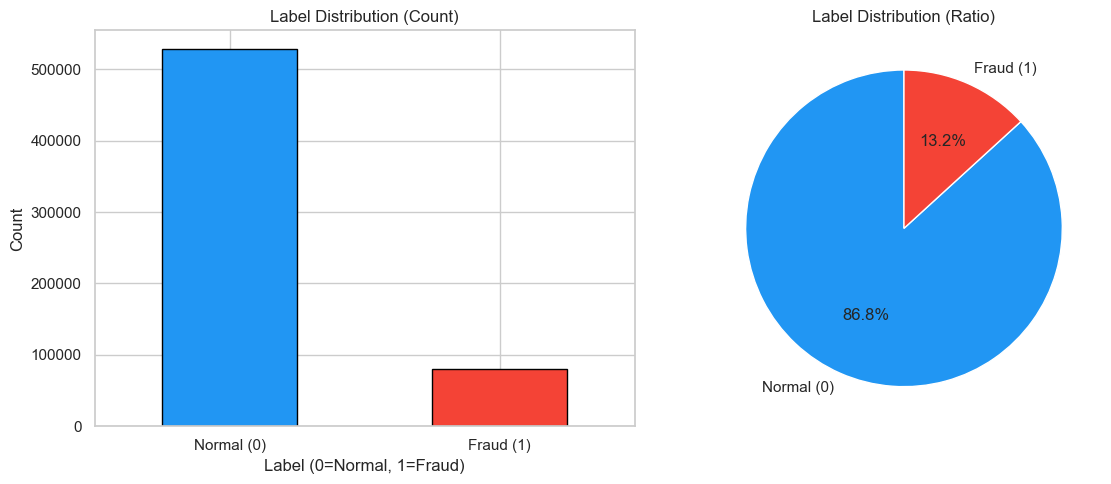

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 카운트
vc.plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Label Distribution (Count)')
axes[0].set_xlabel('Label (0=Normal, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)

# 비율
axes[1].pie(vc, labels=['Normal (0)', 'Fraud (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90)
axes[1].set_title('Label Distribution (Ratio)')

plt.tight_layout()
plt.show()

## 3. 컬럼별 분포 분석

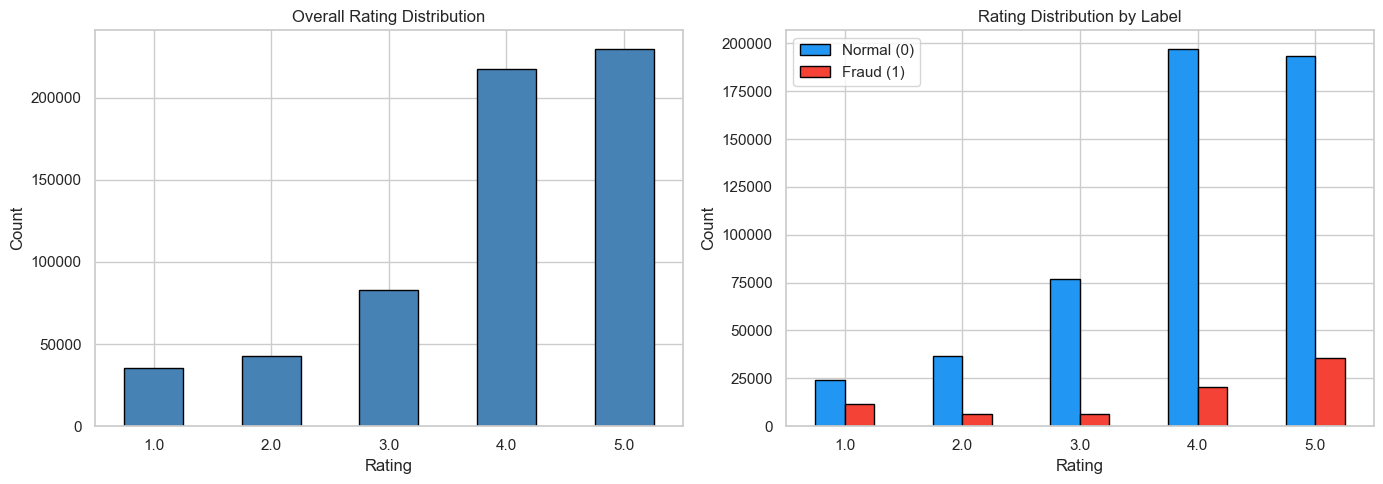

In [28]:
# 별점(rating) 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# 라벨별 별점 분포
df.groupby(['rating', 'label']).size().unstack().plot(
    kind='bar', ax=axes[1], color=['#2196F3', '#F44336'], edgecolor='black'
)
axes[1].set_title('Rating Distribution by Label')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Normal (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()

In [29]:
# 유저별 리뷰 수 분포
user_review_count = df.groupby('user_id').size()
print('=== 유저별 리뷰 수 통계 ===')
print(user_review_count.describe())
print(f'\n리뷰 2개 이상 유저 수: {(user_review_count >= 2).sum():,}')
print(f'리뷰 10개 이상 유저 수: {(user_review_count >= 10).sum():,}')

=== 유저별 리뷰 수 통계 ===
count    260239.000000
mean          2.338074
std           4.495265
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         197.000000
dtype: float64

리뷰 2개 이상 유저 수: 90,163
리뷰 10개 이상 유저 수: 8,453


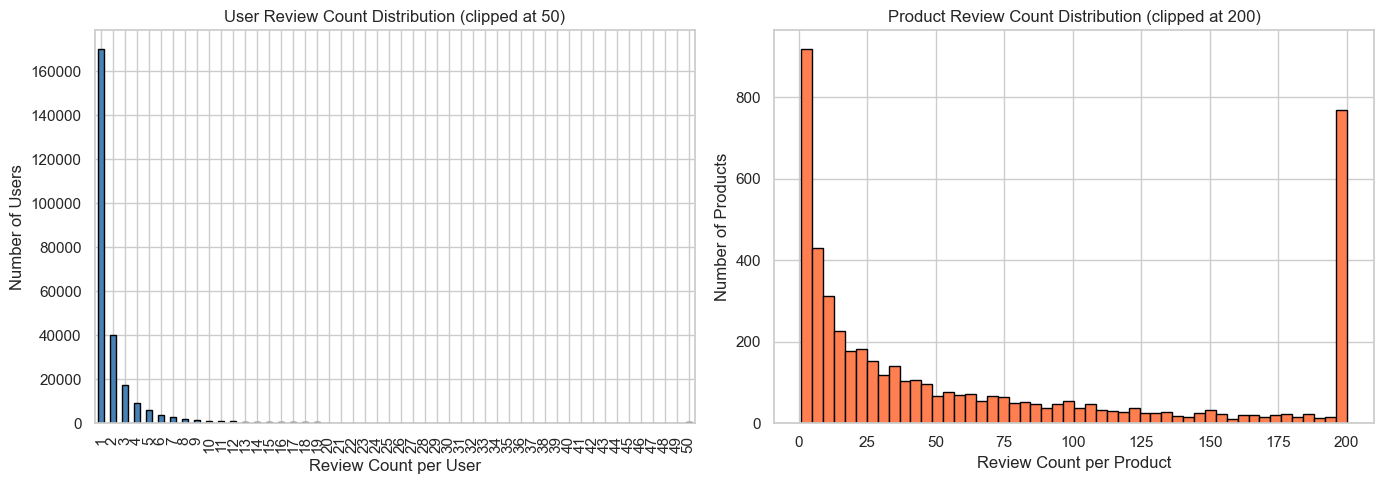

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 유저별 리뷰 수 분포 (상위 50까지)
user_review_count.clip(upper=50).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('User Review Count Distribution (clipped at 50)')
axes[0].set_xlabel('Review Count per User')
axes[0].set_ylabel('Number of Users')

# 상품별 리뷰 수 분포
prod_review_count = df.groupby('prod_id').size()
prod_review_count.clip(upper=200).hist(bins=50, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Product Review Count Distribution (clipped at 200)')
axes[1].set_xlabel('Review Count per Product')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

## 4. 시계열 분석

In [31]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

print(f'날짜 범위: {df["date"].min()} ~ {df["date"].max()}')

날짜 범위: 2004-10-20 00:00:00 ~ 2015-01-10 00:00:00


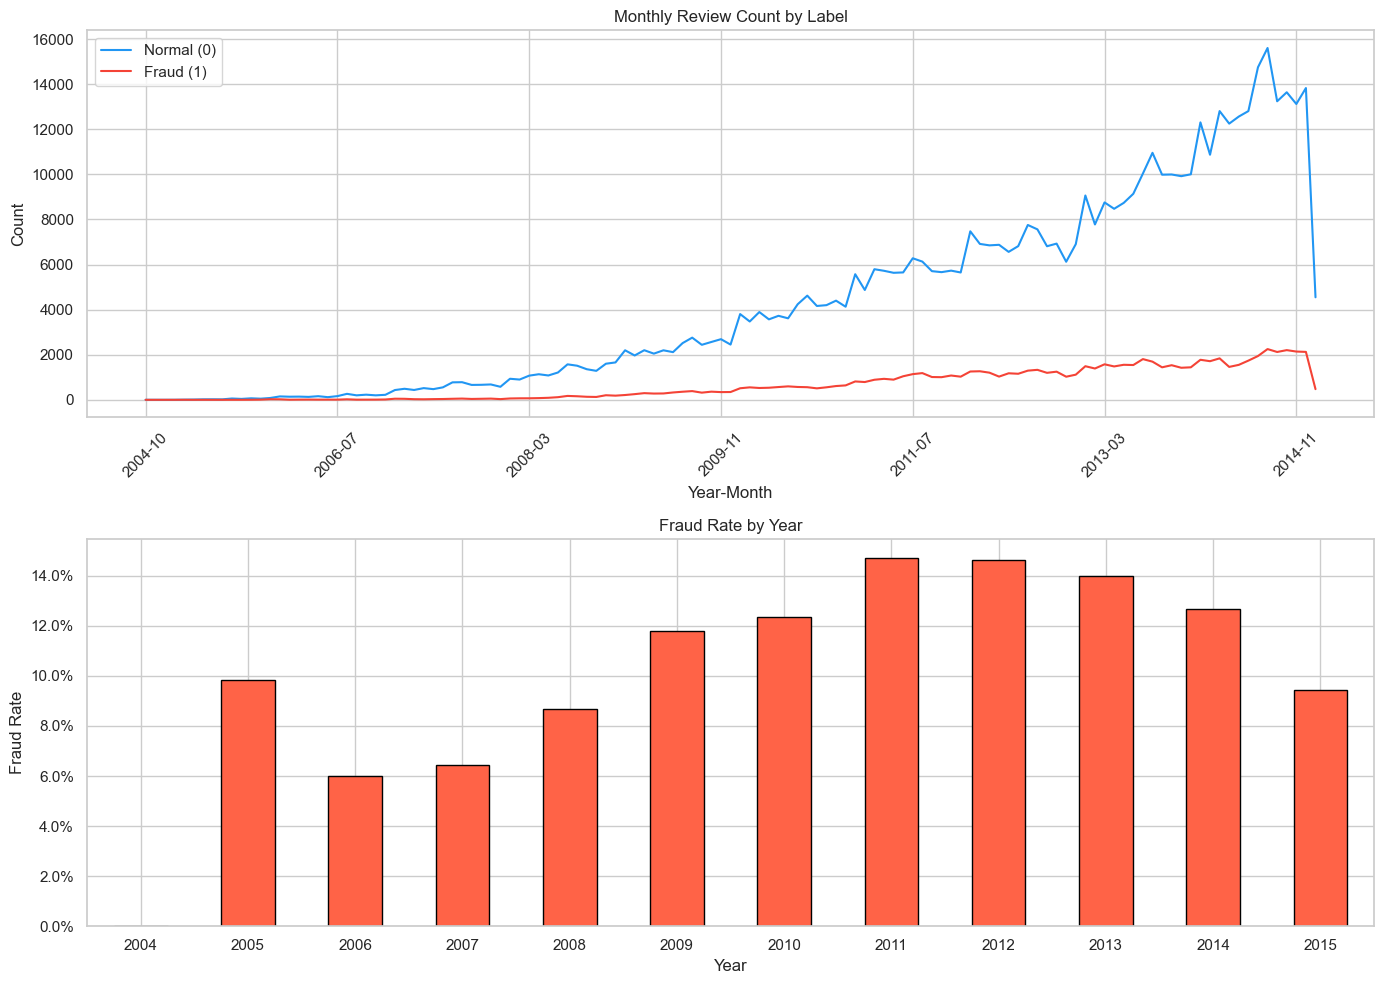

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 월별 리뷰 수 (라벨별)
monthly = df.groupby(['year_month', 'label']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)
monthly.plot(ax=axes[0], color=['#2196F3', '#F44336'])
axes[0].set_title('Monthly Review Count by Label')
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('Count')
axes[0].legend(['Normal (0)', 'Fraud (1)'])
axes[0].tick_params(axis='x', rotation=45)

# 연도별 사기 비율
yearly_fraud_rate = df.groupby('year')['label'].mean()
yearly_fraud_rate.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Fraud Rate by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Fraud Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. 사기/정상 리뷰 텍스트 비교

In [33]:
# 리뷰 텍스트 길이 분석
df['text_len'] = df['text'].fillna('').apply(len)
df['word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))

print('=== 텍스트 길이 (label별) ===')
print(df.groupby('label')[['text_len', 'word_count']].describe().round(1))

=== 텍스트 길이 (label별) ===
       text_len                                                  word_count  \
          count   mean    std  min    25%    50%    75%      max      count   
label                                                                         
0      528019.0  652.7  588.5  1.0  258.0  485.0  856.0  29063.0   528019.0   
1       80439.0  474.2  492.0  1.0  166.0  329.0  607.0   8581.0    80439.0   

                                                     
        mean    std  min   25%   50%    75%     max  
label                                                
0      119.6  107.7  1.0  47.0  89.0  158.0  5333.0  
1       87.1   90.8  1.0  30.0  60.0  112.0  1529.0  


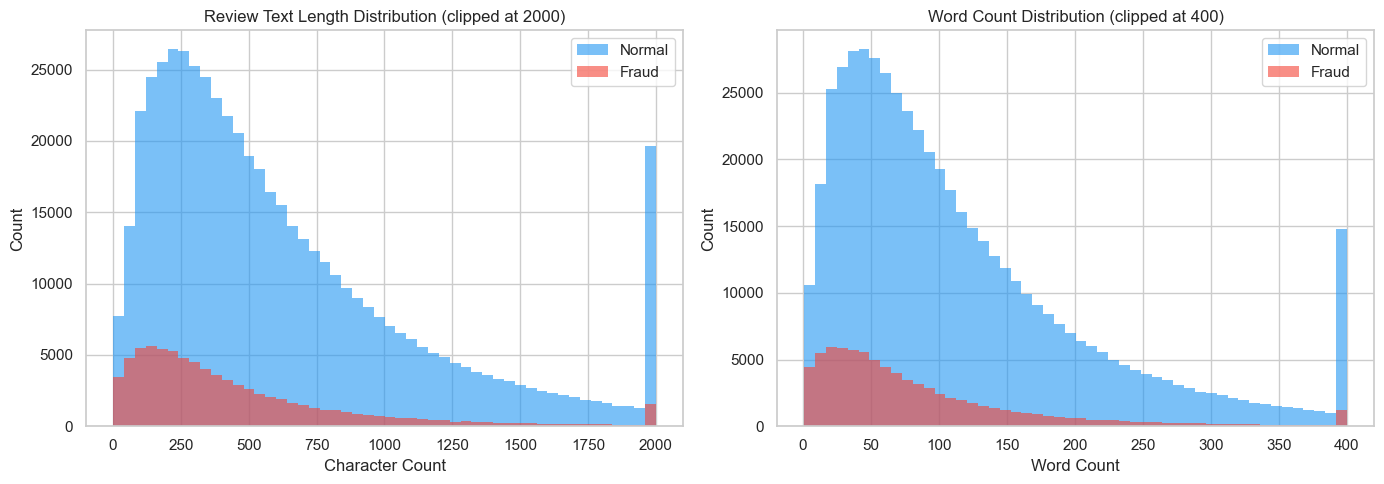

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, '#2196F3', 'Normal'), (1, '#F44336', 'Fraud')]:
    df[df['label'] == label]['text_len'].clip(upper=2000).hist(
        bins=50, ax=axes[0], alpha=0.6, color=color, label=name, edgecolor='none'
    )
    df[df['label'] == label]['word_count'].clip(upper=400).hist(
        bins=50, ax=axes[1], alpha=0.6, color=color, label=name, edgecolor='none'
    )

axes[0].set_title('Review Text Length Distribution (clipped at 2000)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].set_title('Word Count Distribution (clipped at 400)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. 그래프 엣지 설계를 위한 후보 분석

### 기본 Relation 후보
- **R-U-R**: 같은 유저가 작성한 리뷰 간 엣지
- **R-T-R**: 같은 기간(월)에 같은 상품에 쓰인 리뷰 간 엣지
- **R-S-R**: 같은 상품에 같은 별점을 준 리뷰 간 엣지

In [35]:
# R-U-R: 유저당 리뷰 수 (엣지 생성 가능 규모 추정)
rur_candidates = user_review_count[user_review_count >= 2]
rur_edge_estimate = (rur_candidates * (rur_candidates - 1) / 2).sum()
print(f'[R-U-R] 리뷰 2개+ 유저 수: {len(rur_candidates):,}')
print(f'[R-U-R] 예상 엣지 수 (최대): {int(rur_edge_estimate):,}')

[R-U-R] 리뷰 2개+ 유저 수: 90,163
[R-U-R] 예상 엣지 수 (최대): 3,036,448


In [36]:
# R-T-R: 같은 (prod_id, year_month) 그룹 내 리뷰 수
rtr_group = df.groupby(['prod_id', 'year_month']).size()
rtr_candidates = rtr_group[rtr_group >= 2]
rtr_edge_estimate = (rtr_candidates * (rtr_candidates - 1) / 2).sum()
print(f'[R-T-R] 동일 상품+월 그룹 수: {len(rtr_candidates):,}')
print(f'[R-T-R] 예상 엣지 수 (최대): {int(rtr_edge_estimate):,}')

[R-T-R] 동일 상품+월 그룹 수: 85,055
[R-T-R] 예상 엣지 수 (최대): 4,406,863


In [37]:
# R-S-R: 같은 (prod_id, rating) 그룹 내 리뷰 수
rsr_group = df.groupby(['prod_id', 'rating']).size()
rsr_candidates = rsr_group[rsr_group >= 2]
rsr_edge_estimate = (rsr_candidates * (rsr_candidates - 1) / 2).sum()
print(f'[R-S-R] 동일 상품+별점 그룹 수: {len(rsr_candidates):,}')
print(f'[R-S-R] 예상 엣지 수 (최대): {int(rsr_edge_estimate):,}')

[R-S-R] 동일 상품+별점 그룹 수: 17,080
[R-S-R] 예상 엣지 수 (최대): 86,932,344


In [38]:
# 요약
print('=' * 50)
print('      그래프 엣지 설계 요약')
print('=' * 50)
print(f'전체 리뷰(노드) 수 : {len(df):,}')
print(f'고유 유저 수       : {df["user_id"].nunique():,}')
print(f'고유 상품 수       : {df["prod_id"].nunique():,}')
print(f'날짜 범위          : {df["date"].min().date()} ~ {df["date"].max().date()}')
print('=' * 50)

      그래프 엣지 설계 요약
전체 리뷰(노드) 수 : 608,458
고유 유저 수       : 260,239
고유 상품 수       : 5,044
날짜 범위          : 2004-10-20 ~ 2015-01-10


## 7. 라벨 변환 데이터셋 저장

In [39]:
import os

output_path = '../data/yelpzip_label_processed.csv'

df.to_csv(output_path, index=True)

size_mb = os.path.getsize(output_path) / (1024 ** 2)
print(f'저장 완료: {output_path}')
print(f'파일 크기: {size_mb:.2f} MB')
print(f'shape: {df.shape}')
print(f'\nlabel 분포 확인:')
print(df['label'].value_counts())

저장 완료: ../data/yelpzip_label_processed.csv
파일 크기: 404.97 MB
shape: (608458, 12)

label 분포 확인:
label
0    528019
1     80439
Name: count, dtype: int64


## 다음 단계
- `02_subgraph_sampling.ipynb` — 서브그래프 샘플링 (1만~5만 노드)
- `03_graph_construction.ipynb` — 엣지 구성 및 커스텀 Relation 설계
- `04_gnn_modeling.ipynb` — GNN 모델 학습 및 성능 평가